# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [21]:
#Type your code here
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import silhouette_score
from google.colab import drive
from sqlalchemy import create_engine

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
#Type your code here
drive.mount('/content/drive')
# Load dataset
df = pd.read_csv("customer_churn_dataset-testing-master.csv")

# Tampilkan 5 baris pertama
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


Tidak ada missing value

In [24]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


Tidak ada baris yang kosong

In [25]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


*   Tidak ada data duplikat karena total data 64374 terhitung dari 1 sampai 64374
*   Churn: Ini adalah variabel biner (0 atau 1). Nilai rata-rata sebesar 0,473685 menunjukkan bahwa sekitar 47,37% pelanggan dalam kumpulan data (dataset) ini telah berhenti berlangganan (churn). Hal ini mengindikasikan tingkat perpindahan pelanggan yang cukup tinggi.



# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [26]:
# Mengidentifikasi kolom numerik yang akan distandarisasi
# CustomerID dan Churn dikecualikan karena ID dan variabel target
numerical_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                  'Payment Delay', 'Total Spend', 'Last Interaction']

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Menerapkan StandardScaler pada kolom numerik
df_scaled = df.copy() # Buat salinan DataFrame agar data asli tidak berubah
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print("DataFrame setelah standarisasi fitur numerik:")
display(df_scaled[numerical_cols].head())

DataFrame setelah standarisasi fitur numerik:


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
0,-1.434202,-0.409100,-0.122526,-0.449807,1.114538,0.218408,-0.752324
1,-0.069730,-0.233642,1.465424,0.513590,-0.467000,0.164742,0.521065
2,0.361155,-0.292128,-0.576225,-1.092072,1.340472,0.827900,0.636827
3,-0.500616,-1.344876,-0.349375,-0.128674,-0.015132,-1.184575,0.289540
4,0.792041,1.520939,1.011724,1.155855,-1.709637,-0.030756,0.289540


### Visualisasi Distribusi Fitur Numerik (Sebelum Scaling)

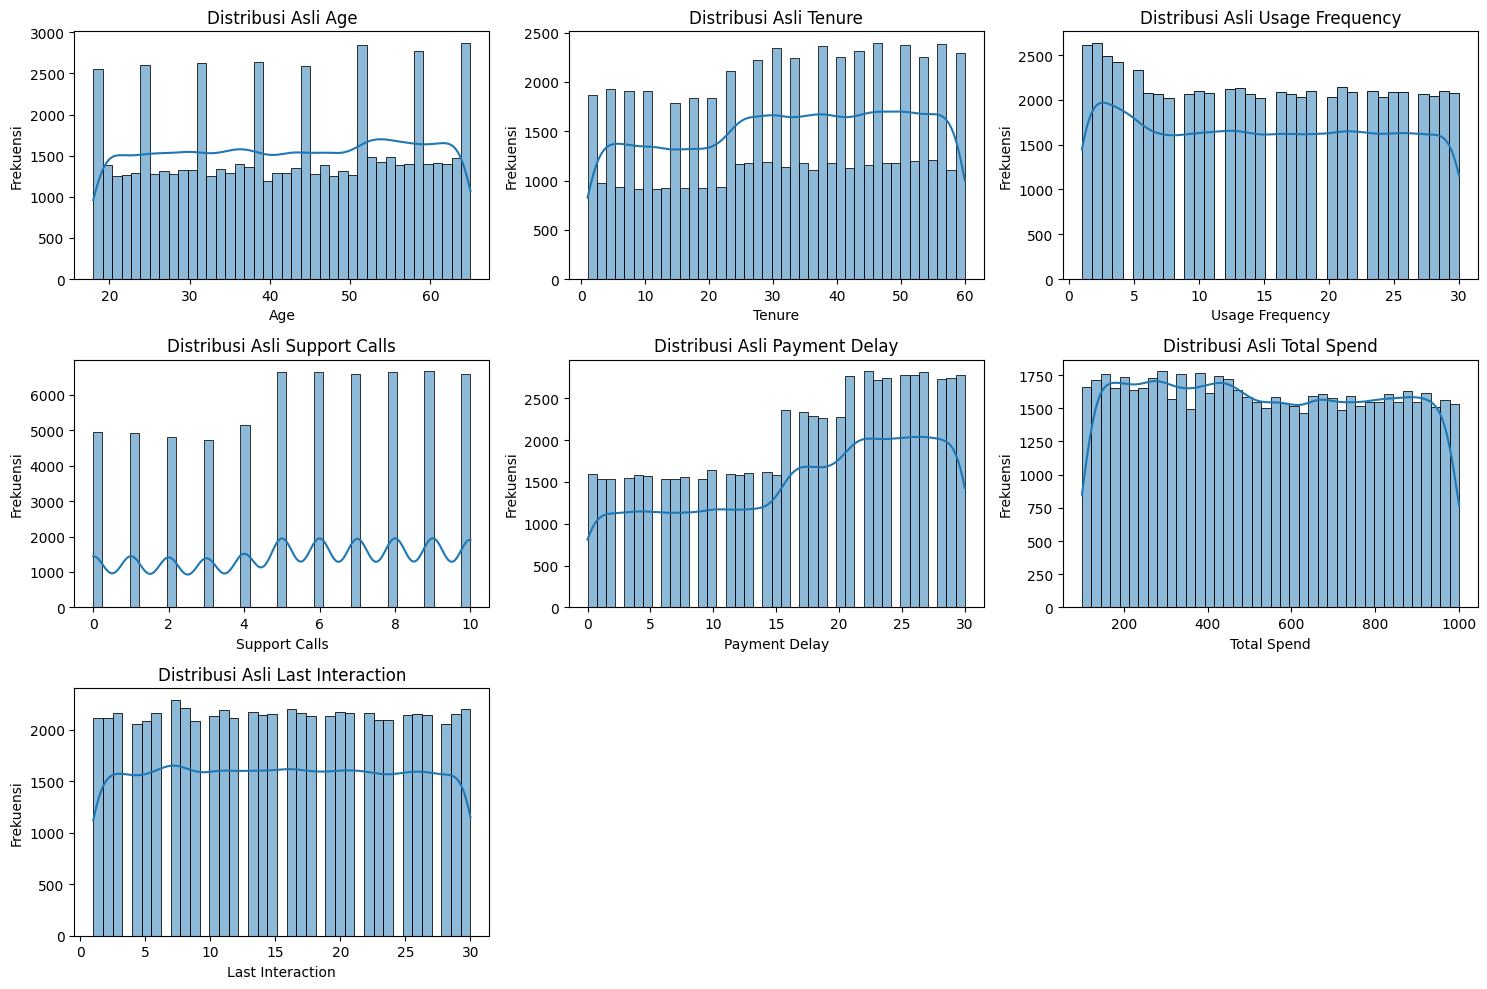

In [27]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi Asli {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

### Visualisasi Distribusi Fitur Numerik (Setelah Scaling)

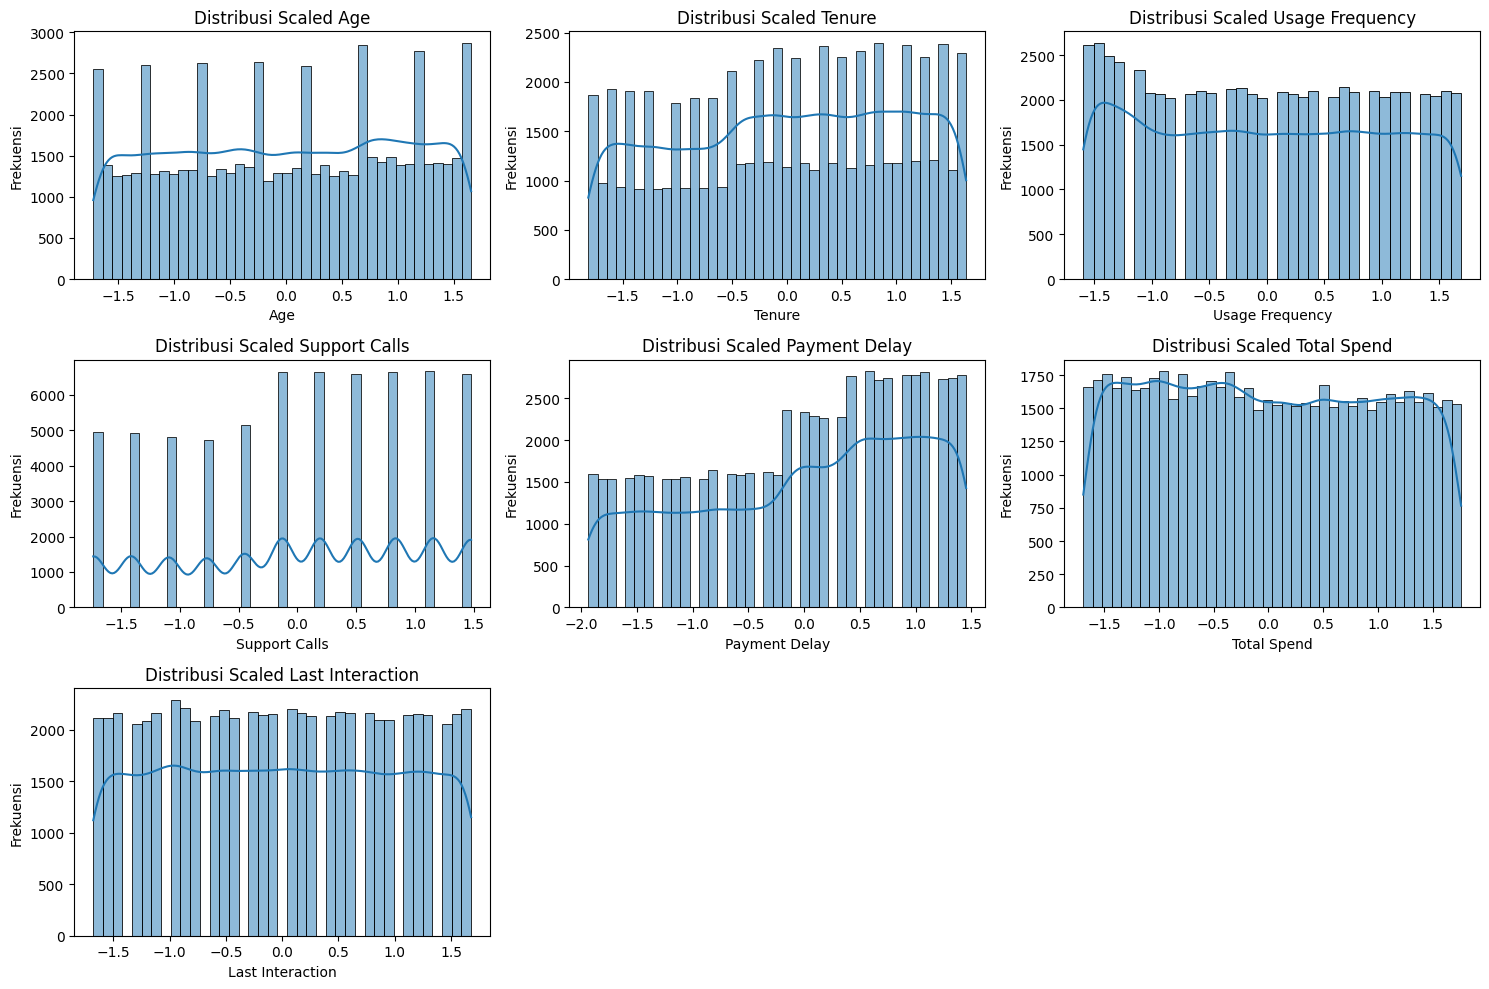

In [28]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(df_scaled[col], kde=True)
    plt.title(f'Distribusi Scaled {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

### Visualisasi Outlier

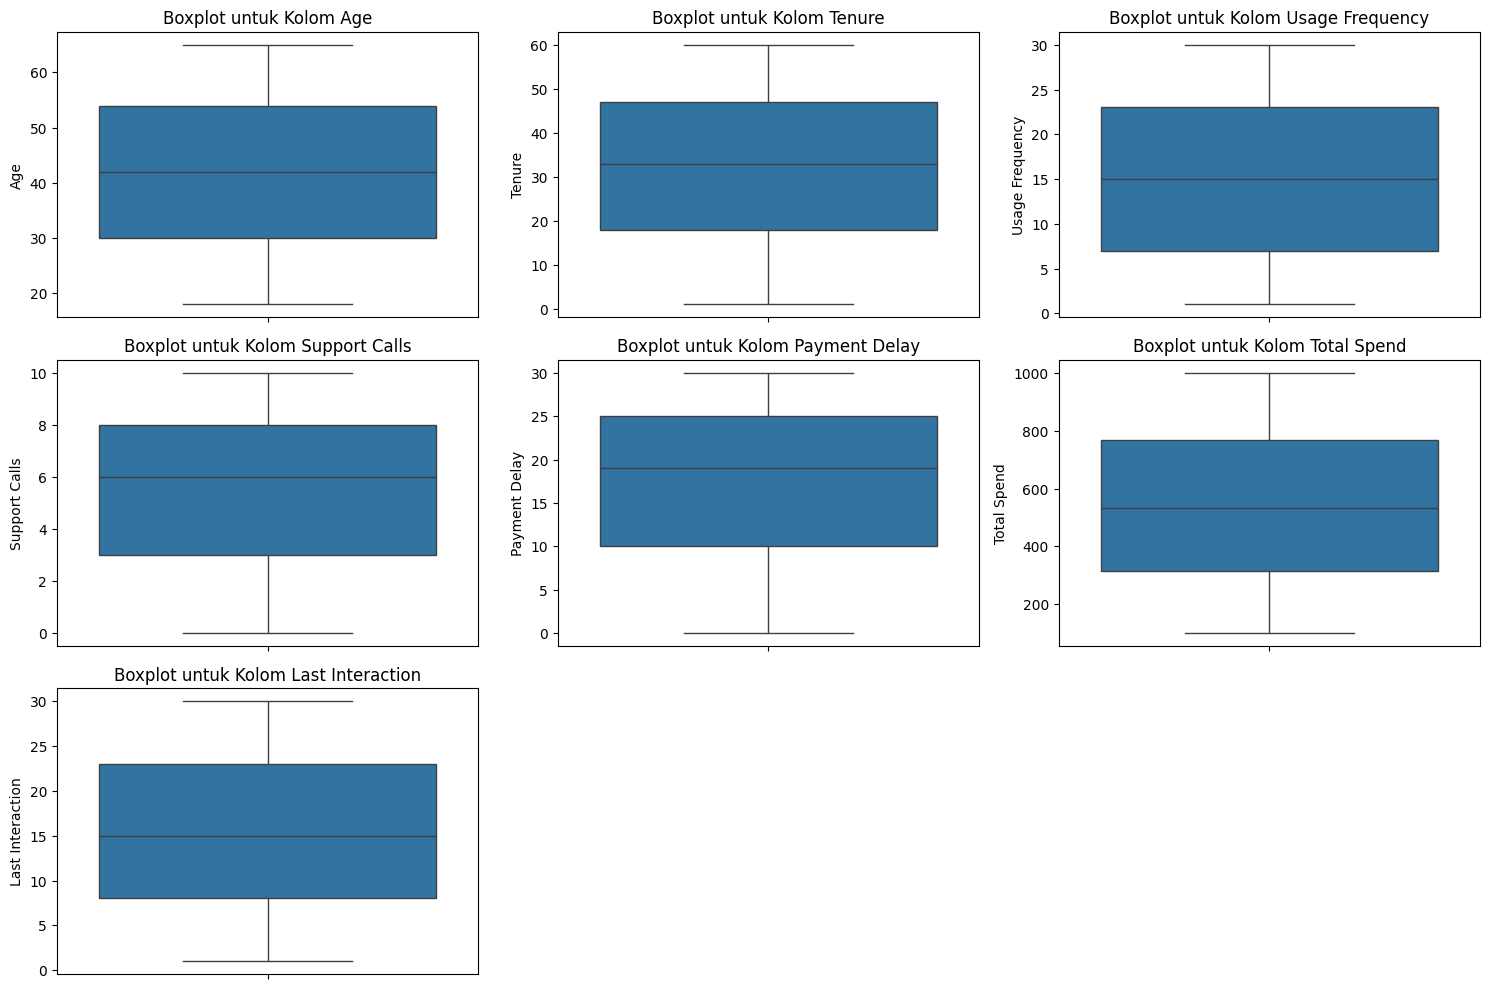

In [29]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Sesuaikan grid subplot jika perlu
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot untuk Kolom {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [30]:
print("Deteksi Outlier menggunakan Metode IQR:")
outlier_counts = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

    print(f"Kolom '{col}':")
    print(f"  Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"  Batas Bawah: {lower_bound}, Batas Atas: {upper_bound}")
    print(f"  Jumlah Outlier: {len(outliers)}\n")

print("Ringkasan Jumlah Outlier per Kolom:")
for col, count in outlier_counts.items():
    print(f"  {col}: {count} outliers")

Deteksi Outlier menggunakan Metode IQR:
Kolom 'Age':
  Q1: 30.0, Q3: 54.0, IQR: 24.0
  Batas Bawah: -6.0, Batas Atas: 90.0
  Jumlah Outlier: 0

Kolom 'Tenure':
  Q1: 18.0, Q3: 47.0, IQR: 29.0
  Batas Bawah: -25.5, Batas Atas: 90.5
  Jumlah Outlier: 0

Kolom 'Usage Frequency':
  Q1: 7.0, Q3: 23.0, IQR: 16.0
  Batas Bawah: -17.0, Batas Atas: 47.0
  Jumlah Outlier: 0

Kolom 'Support Calls':
  Q1: 3.0, Q3: 8.0, IQR: 5.0
  Batas Bawah: -4.5, Batas Atas: 15.5
  Jumlah Outlier: 0

Kolom 'Payment Delay':
  Q1: 10.0, Q3: 25.0, IQR: 15.0
  Batas Bawah: -12.5, Batas Atas: 47.5
  Jumlah Outlier: 0

Kolom 'Total Spend':
  Q1: 313.0, Q3: 768.0, IQR: 455.0
  Batas Bawah: -369.5, Batas Atas: 1450.5
  Jumlah Outlier: 0

Kolom 'Last Interaction':
  Q1: 8.0, Q3: 23.0, IQR: 15.0
  Batas Bawah: -14.5, Batas Atas: 45.5
  Jumlah Outlier: 0

Ringkasan Jumlah Outlier per Kolom:
  Age: 0 outliers
  Tenure: 0 outliers
  Usage Frequency: 0 outliers
  Support Calls: 0 outliers
  Payment Delay: 0 outliers
  Total S

### Encoding Data Kategorikal (One-Hot Encoding)

_One-Hot Encoding_ adalah metode untuk mengubah variabel kategorikal menjadi format numerik biner, di mana setiap kategori diwakili oleh kolom biner baru (0 atau 1). Ini penting karena sebagian besar algoritma _machine learning_ tidak dapat bekerja secara langsung dengan data teks kategorikal.

Saya akan menerapkan _one-hot encoding_ pada kolom `Gender`, `Subscription Type`, dan `Contract Length`.

In [31]:
# Mengidentifikasi kolom kategorikal
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']

# Menerapkan one-hot encoding
df_encoded = pd.get_dummies(df_scaled, columns=categorical_cols, drop_first=True) # drop_first=True untuk menghindari multicollinearity

print("DataFrame setelah one-hot encoding:")
display(df_encoded.head())

DataFrame setelah one-hot encoding:


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,1,-1.434202,-0.409100,-0.122526,-0.449807,1.114538,0.218408,-0.752324,1,False,False,False,True,False
1,2,-0.069730,-0.233642,1.465424,0.513590,-0.467000,0.164742,0.521065,0,False,False,True,True,False
2,3,0.361155,-0.292128,-0.576225,-1.092072,1.340472,0.827900,0.636827,0,True,True,False,False,False
3,4,-0.500616,-1.344876,-0.349375,-0.128674,-0.015132,-1.184575,0.289540,0,True,True,False,False,True
4,5,0.792041,1.520939,1.011724,1.155855,-1.709637,-0.030756,0.289540,0,False,False,True,False,False


### Binning (Pengelompokan Data)

_Binning_ atau pengelompokan data adalah proses mengelompokkan nilai-nilai numerik kontinu ke dalam sejumlah interval diskrit atau 'bin'. Ini dapat membantu dalam beberapa hal:
*   **Mengurangi sensitivitas terhadap _noise_**: Mengurangi variasi kecil dalam data.
*   **Membuat pola lebih jelas**: Mengubah data kontinu menjadi kategorikal sehingga lebih mudah diinterpretasi, terutama untuk model yang bekerja lebih baik dengan data kategorikal.
*   **Mengurangi jumlah nilai unik**: Berguna untuk fitur dengan banyak nilai unik.

Saya akan membuat grup usia (bins) dari kolom `Age`.

In [32]:
# Menentukan batas-batas bin untuk kolom 'Age'
age_bins = [18, 25, 35, 45, 55, 65] # Contoh batas usia
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-65'] # Label untuk setiap bin

# Menerapkan binning pada kolom 'Age'
df_encoded['Age_Group'] = pd.cut(df_encoded['Age'], bins=age_bins, labels=age_labels, right=False)

print("DataFrame setelah binning kolom 'Age':")
display(df_encoded[['Age', 'Age_Group']].head())

DataFrame setelah binning kolom 'Age':


,Age,Age_Group
0,-1.434202,NaN
1,-0.069730,NaN
2,0.361155,NaN
3,-0.500616,NaN
4,0.792041,NaN


### Encoding Kolom 'Age_Group' (One-Hot Encoding)

Setelah melakukan binning pada kolom 'Age' menjadi 'Age_Group', kolom baru ini bersifat kategorikal. Untuk dapat digunakan dalam model _machine learning_, kita perlu mengubahnya menjadi format numerik menggunakan _one-hot encoding_.

In [33]:
# Menerapkan one-hot encoding pada kolom 'Age_Group'
df_final = pd.get_dummies(df_encoded, columns=['Age_Group'], drop_first=True)

# Menampilkan kolom yang relevan setelah encoding 'Age_Group'
print("DataFrame setelah one-hot encoding 'Age_Group':")
display(df_final.head())

DataFrame setelah one-hot encoding 'Age_Group':


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly,Age_Group_25-34,Age_Group_35-44,Age_Group_45-54,Age_Group_55-65
0,1,-1.434202,-0.409100,-0.122526,-0.449807,1.114538,0.218408,-0.752324,1,False,False,False,True,False,False,False,False,False
1,2,-0.069730,-0.233642,1.465424,0.513590,-0.467000,0.164742,0.521065,0,False,False,True,True,False,False,False,False,False
2,3,0.361155,-0.292128,-0.576225,-1.092072,1.340472,0.827900,0.636827,0,True,True,False,False,False,False,False,False,False
3,4,-0.500616,-1.344876,-0.349375,-0.128674,-0.015132,-1.184575,0.289540,0,True,True,False,False,True,False,False,False,False
4,5,0.792041,1.520939,1.011724,1.155855,-1.709637,-0.030756,0.289540,0,False,False,True,False,False,False,False,False,False


### Pembagian Data Latih dan Data Uji (Train-Test Split)

Langkah selanjutnya dalam persiapan data adalah membagi dataset menjadi dua bagian: data latih (_training data_) dan data uji (_testing data_).

*   **Data Latih** digunakan untuk melatih model _machine learning_.
*   **Data Uji** digunakan untuk mengevaluasi kinerja model pada data yang belum pernah dilihat sebelumnya.

Pembagian ini penting untuk memastikan bahwa model tidak hanya menghafal data latih (_overfitting_) tetapi juga dapat digeneralisasi dengan baik pada data baru.

In [34]:

# Definisikan fitur (X) dan variabel target (y)
# Menghilangkan 'CustomerID', 'Churn', dan 'Age' dari fitur
X = df_final.drop(['CustomerID', 'Churn', 'Age'], axis=1)
y = df_final['Churn']

# Lakukan pembagian data latih dan data uji
# test_size=0.2 berarti 20% data akan menjadi data uji
# random_state=42 untuk memastikan hasil yang dapat direproduksi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Ukuran data latih (X_train):", X_train.shape)
print("Ukuran data uji (X_test):", X_test.shape)
print("Ukuran target latih (y_train):", y_train.shape)
print("Ukuran target uji (y_test):", y_test.shape)

Ukuran data latih (X_train): (51499, 15)
Ukuran data uji (X_test): (12875, 15)
Ukuran target latih (y_train): (51499,)
Ukuran target uji (y_test): (12875,)


In [ ]:
# Tentukan jalur folder di Google Drive kamu (misal di folder utama My Drive)
# Sesuai instruksi: Eksperimen_SML_Nama-kamu/preprocessing/namadataset_preprocessing/
drive_path = 'preprocessing\'

# Buat foldernya secara otomatis di Drive
os.makedirs(drive_path, exist_ok=True)

# Ekspor langsung ke Google Drive
df.to_csv(os.path.join(drive_path, 'customer_churn_preprocessing.csv'), index=False)
print("Data sukses dibersihkan dan langsung tersimpan di Google Drive kamu!")

Data sukses dibersihkan dan langsung tersimpan di Google Drive kamu!


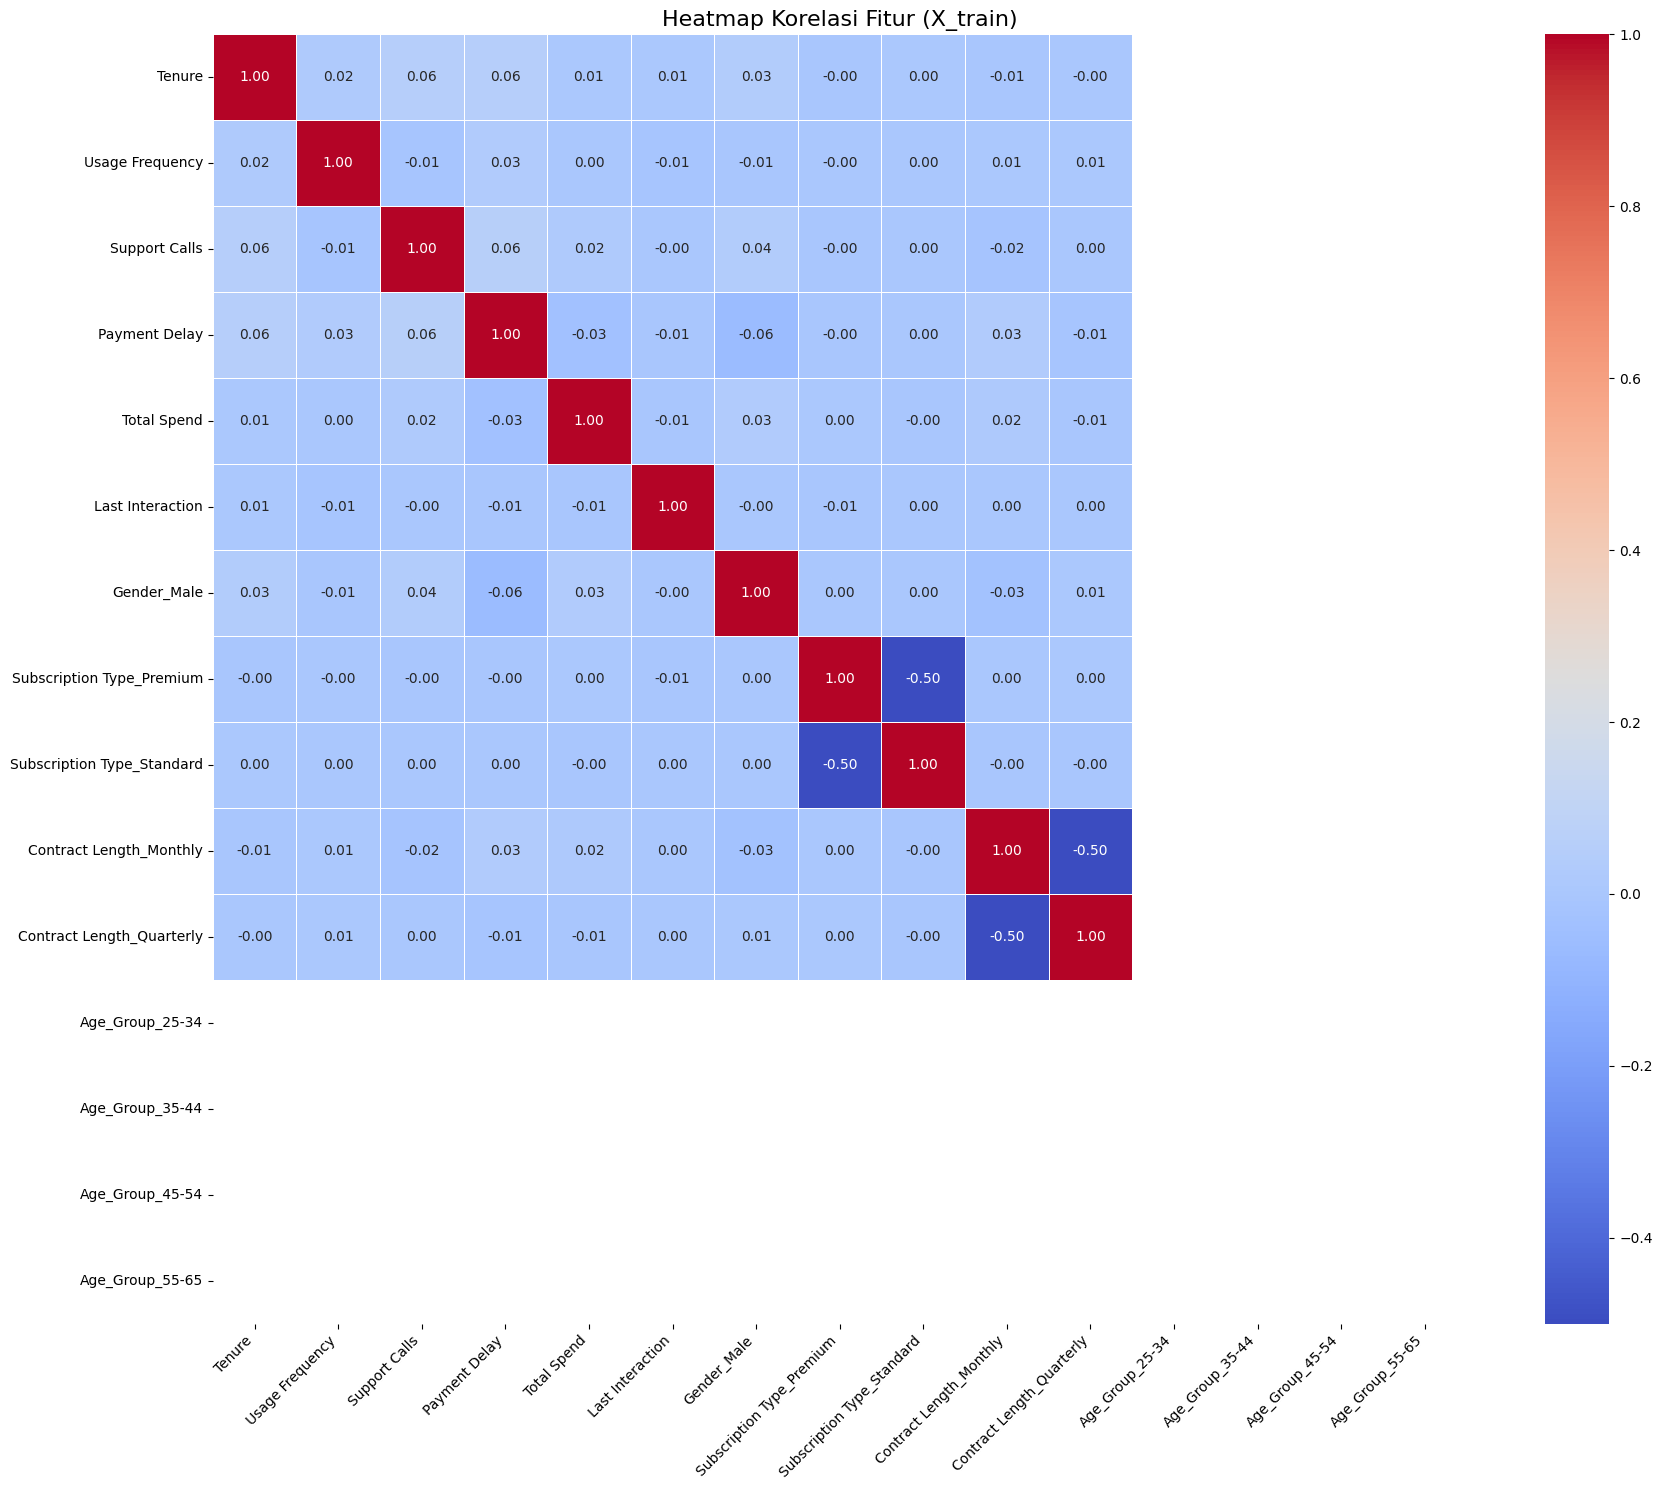

In [36]:
# Hitung matriks korelasi dari data latih (X_train)
correlation_matrix = X_train.corr()

# Buat heatmap korelasi
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Fitur (X_train)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Perbandingan 'Total Spend' antara Churner dan Non-Churner (Box Plot)

Untuk memahami lebih lanjut faktor-faktor yang memengaruhi _churn rate_, kita akan membandingkan distribusi 'Total Spend' antara pelanggan yang _churn_ (berhenti berlangganan) dan yang tidak _churn_. _Box plot_ sangat efektif untuk visualisasi perbandingan distribusi ini, menunjukkan median, kuartil, dan potensi _outlier_.

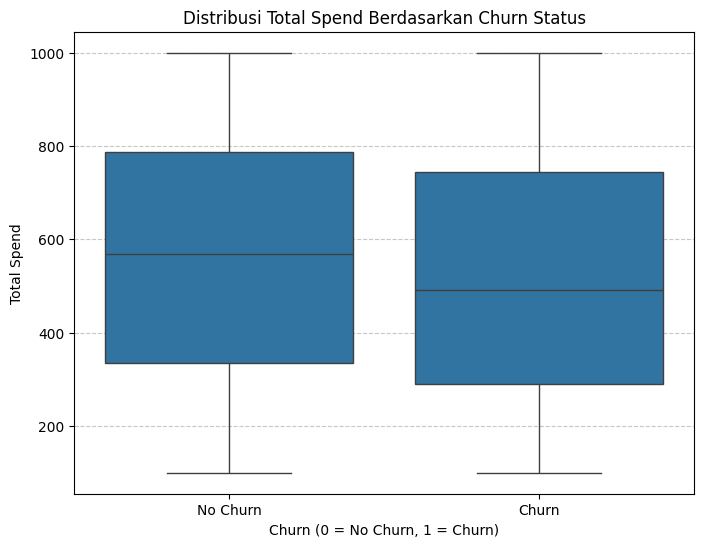

In [37]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Total Spend', data=df)
plt.title('Distribusi Total Spend Berdasarkan Churn Status')
plt.xlabel('Churn (0 = No Churn, 1 = Churn)')
plt.ylabel('Total Spend')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Pelanggan yang memiliki nilai Total Spend lebih tinggi memiliki kecenderungan lebih besar untuk bertahan (No Churn). Sebaliknya, pelanggan dengan pengeluaran yang lebih rendah atau bermigrasi ke nilai transaksi kecil lebih rentan untuk melakukan churn.

### Menentukan Jumlah Tipe Pelanggan (Segmentasi Pelanggan)

Untuk menjawab pertanyaan "Ada berapa tipe pelanggan?", kita dapat menggunakan teknik _clustering_, seperti K-Means. Namun, sebelum menerapkan K-Means, penting untuk menentukan jumlah _cluster_ (K) yang optimal. Kita akan menggunakan dua metode umum untuk ini:

1.  **Metode Elbow**: Melihat _Within-Cluster Sum of Squares_ (WCSS) untuk berbagai nilai K. Titik di mana penurunan WCSS mulai melambat ("siku") sering kali menunjukkan nilai K yang optimal.
2.  **Skor Silhouette**: Mengukur seberapa mirip suatu objek dengan _cluster_nya sendiri (kohesi) dibandingkan dengan _cluster_ lain (separasi). Nilai skor Silhouette yang lebih tinggi menunjukkan _cluster_ yang lebih baik.

#### Metode Elbow untuk Menentukan K Optimal

Kita akan menghitung WCSS untuk sejumlah nilai K yang berbeda dan memvisualisasikannya.

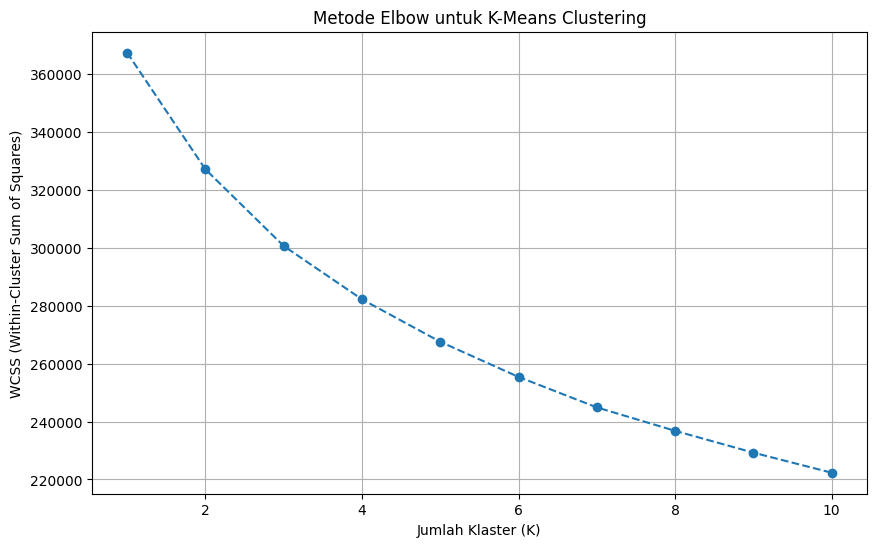

In [38]:
wcss = []
# Mencoba K dari 1 hingga 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metode Elbow untuk K-Means Clustering')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

#### Skor Silhouette untuk Menentukan K Optimal

Selanjutnya, kita akan menghitung skor Silhouette untuk berbagai nilai K. Nilai tertinggi menunjukkan _clustering_ yang lebih baik.

In [ ]:
silhouette_scores = []
# Mencoba K dari 2 hingga 10 (Silhouette Score tidak terdefinisi untuk K=1)
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_train)
    score = silhouette_score(X_train, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Skor Silhouette untuk K-Means Clustering')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Skor Silhouette')
plt.grid(True)
plt.show()

### Penerapan K-Means Clustering dengan K=2

Berdasarkan hasil analisis metode Elbow dan Silhouette Score yang mengindikasikan K=2 sebagai jumlah klaster yang optimal, kita akan menerapkan algoritma K-Means untuk mengelompokkan pelanggan ke dalam dua tipe yang berbeda. Setelah itu, kita akan menganalisis karakteristik dari setiap klaster untuk memahami profil pelanggan.

In [ ]:
# Terapkan K-Means dengan K=2
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train)

# Tambahkan label klaster ke DataFrame X_train
X_train_clustered = X_train.copy()
X_train_clustered['Cluster'] = clusters

print("Distribusi pelanggan di setiap klaster:")
display(X_train_clustered['Cluster'].value_counts())

print("\nRingkasan karakteristik fitur per klaster:")
cluster_summary = X_train_clustered.groupby('Cluster').mean()
display(cluster_summary)

### Ringkasan Tipe Pelanggan (Segmentasi)

Berdasarkan analisis karakteristik rata-rata fitur di setiap klaster, kita dapat merangkum tipe-tipe pelanggan sebagai berikut:

#### Klaster 0: Pelanggan Stabil dan Memiliki Risiko Churn Rendah

*   **Karakteristik Utama:**
    *   **Penundaan Pembayaran (Payment Delay):** Cenderung memiliki penundaan pembayaran yang jauh lebih rendah (-1.027), menunjukkan kedisiplinan dalam pembayaran.
    *   **Panggilan Dukungan (Support Calls):** Memiliki jumlah panggilan dukungan yang lebih sedikit (-0.228), mengindikasikan pengalaman yang lebih mulus atau jarang menghadapi masalah.
    *   **Pengeluaran Total (Total Spend):** Sedikit lebih tinggi (0.077), menunjukkan nilai pelanggan yang baik.
    *   **Jenis Kontrak:** Sedikit kurang cenderung memiliki kontrak bulanan (0.325) dan lebih cenderung memiliki Gender Pria (0.500).

*   **Profil Pelanggan:** Kelompok ini mewakili pelanggan yang relatif puas, mandiri, dan tidak sering memerlukan bantuan. Mereka adalah fondasi pelanggan yang stabil dan berharga bagi perusahaan.

#### Klaster 1: Pelanggan Berisiko dan Membutuhkan Perhatian Lebih

*   **Karakteristik Utama:**
    *   **Penundaan Pembayaran (Payment Delay):** Cenderung memiliki penundaan pembayaran yang lebih tinggi (0.688), menunjukkan potensi masalah finansial atau ketidakpuasan terhadap layanan.
    *   **Panggilan Dukungan (Support Calls):** Memiliki jumlah panggilan dukungan yang lebih banyak (0.151), mengindikasikan mereka sering menghadapi masalah atau memerlukan bantuan.
    *   **Tenur (Tenure):** Memiliki nilai Tenure yang sedikit lebih tinggi (0.139) dan Usage Frequency (0.058), namun disertai dengan masalah yang lebih tinggi (Payment Delay, Support Calls).
    *   **Pengeluaran Total (Total Spend):** Sedikit lebih rendah (-0.052), yang, berdasarkan analisis sebelumnya, merupakan indikator risiko churn.
    *   **Jenis Kontrak:** Sedikit lebih cenderung memiliki kontrak bulanan (0.358).

*   **Profil Pelanggan:** Kelompok ini adalah pelanggan yang berisiko tinggi untuk _churn_. Meskipun mereka mungkin telah menjadi pelanggan untuk jangka waktu yang lebih lama (Tenure yang lebih tinggi), masalah-masalah seperti penundaan pembayaran dan seringnya panggilan dukungan menunjukkan bahwa mereka kurang puas atau mengalami kesulitan. Mereka memerlukan intervensi proaktif, seperti penawaran khusus atau dukungan pelanggan yang ditingkatkan, untuk mencegah mereka beralih.